# GenX scenario overview 
## MIT Energy Initiative Future of Fusion study

### Imports

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import sys
import os
import seaborn as sns
import numpy as np

from pprint import pprint
from matplotlib.ticker import (MultipleLocator, AutoMinorLocator)
import matplotlib.dates as mdates

### Functions

In [2]:
def year_filtering_module(year_list, nb_years):
    """Return the list of timeindex for the selected year.
    
    Input:
    - [list] year: simulated years to select in the global dataset (1 - nb_years);
    - [int] nb_years: number of years simulated in the global dataset.
    
    Output:
    - [list] timeindex: list of hours to include in the subsequent analysis.
    """
    if isinstance(year_list, list):
        to_be_returned = []
        for y in year_list:
            if y > nb_years or y == 0:
                raise ValueError(f"Selected year ({y}) out of range [1 - {nb_years}]. Please select a year that has been simualted.")
            #end if
            to_be_returned.append([8760*(y-1) + 1 + j for j in range(8760)])
        #end for
        return to_be_returned
    else:
        raise TypeError(f"Selected years should be a list (e.g. [1,3,17]).")
    #end if
    

In [10]:
scenarios_list = []

with open('..\segment_scenarios_generation\Scenario_list.txt', 'r') as file:
    lines = file.readlines()

    for line in lines:
        line_scenario = []
        for y in line.split():
            line_scenario.append(int(y))
        # line_scenario.append(int(y) for y in line.split())
        # print(line_scenario)
        scenarios_list.append(line_scenario)
    # end for

## Scenario importation

In [5]:
sub_scenario_name = 'OK_Cost_3000.0_EmissLevel_4.0_gCO2perkWh'
# sub_scenario_name = 'FlexibleDemand100MW4hr_Cost_3000.0_EmissLevel_4.0_gCO2perkWh'
# sub_scenario_name = 'CapaForced_SideTES_Cost_3000.0_EmissLevel_4.0_gCO2perkWh'
# sub_scenario_name = 'Cost_3000.0_EmissLevel_50.0_gCO2perkWh'
# sub_scenario_name = 'FPPMaxFree_5000MW_8h_INFh_TES_Cost_3000.0_EmissLevel_4.0_gCO2perkWh'
# sub_scenario_name = 'CheapTES_Cost_3000.0_EmissLevel_4.0_gCO2perkWh'
sub_scenario_name = 'NoTES_Cost_3000.0_EmissLevel_4.0_gCO2perkWh'


In [8]:
scenario_dict = {}
directory = './Scenarios/'


i = 1
for scenario in os.listdir(directory):
    treated_path = f"{directory}{scenario}/Results/{sub_scenario_name}/Treated_Output"
    nb_years_simulated = len(scenarios_list[int(scenario.split('_')[1])])
    if os.path.exists(treated_path):
        if not len(os.listdir(treated_path)) < nb_years_simulated:
            scenario_dict.update({i-1 : scenario})
            i += 1
        # end if
    # end if
# end for

print("Please select the index of one scenario to overview")
pprint(scenario_dict)
user_choice = input("Your choice (int) ?   ")
default_choice = min(len(scenario_dict)-1,22)
choice = int(user_choice or default_choice)
scenario_selected = scenario_dict[choice]
print("")
if user_choice == "":
    print(f"You selected {choice}:  {scenario_dict[choice]} (default)")
else:
    print(f"You selected {choice}:  {scenario_dict[choice]}")

Please select the index of one scenario to overview
{0: 'Scenario_01', 1: 'Scenario_04', 2: 'Scenario_15'}

You selected 1:  Scenario_04


In [11]:
Gross_load = f"{directory}{scenario_selected}/Load_data.csv"
Gross_variability = f"{directory}{scenario_selected}/Generators_variability.csv"

nb_years_simulated = len(scenarios_list[int(scenario_selected.split('_')[1])])
year_labels = scenarios_list[int(scenario_selected.split('_')[1])]

# Modify here the years to be extracted
# year_list = [i for i in range(1, nb_years_simulated+1)] 
# year_list = [14, 17, 20]
year_list = year_labels
nb_years = len(year_list)

dict_df_years = {}
i = 0

for y in year_list:
    j = (i + 1)/nb_years
    sys.stdout.write('\r')
    sys.stdout.write(f"[%-20s] %d%%  ---  Dataframes loaded for year {y}!" % ('='*int(20*j), 100*j))
    # sys.stdout.flush()

    path_y = f"{directory}{scenario_selected}/Results/{sub_scenario_name}/Treated_Output/year_{y}.csv"
    df_y = pd.read_csv(path_y, index_col=0)

    # print(f"Dataframes loaded for year {y}!")
    
    dict_df_years.update({y:df_y})
    i += 1
# end for

[====================] 100%  ---  Dataframes loaded for year 4!

## Data plots

### Boolean graph selectors

In [12]:
Historical_plot_bool = True
Temporal_segment_bool = True
autocorr_bool = True
Variability_plot_bool = False
Price_duration_curve_bool = True
Available_FPP_energy_bool = True
TES_maximal_level_bool = False
Storage_profit_profile_bool = False
Price_distribution_bool = False
TES_normalized_level_bool = True
TES_variables_analysis_bool = False
TES_profitability_threshold_bool = True


# Historical_plot_bool = True
# Temporal_segment_bool = True
# autocorr_bool = True
# Variability_plot_bool = True
# Price_duration_curve_bool = True
# Available_FPP_energy_bool = True
# TES_maximal_level_bool = True
# Storage_profit_profile_bool = True
# Price_distribution_bool = True
# TES_normalized_level_bool = True
# TES_variables_analysis_bool = True
# TES_profitability_threshold_bool = True

### Historical load/price and storage plots

The plot below is resticted to a small time window to ensure legibility

[====================] 100%  ---  Plot ready for year 4!

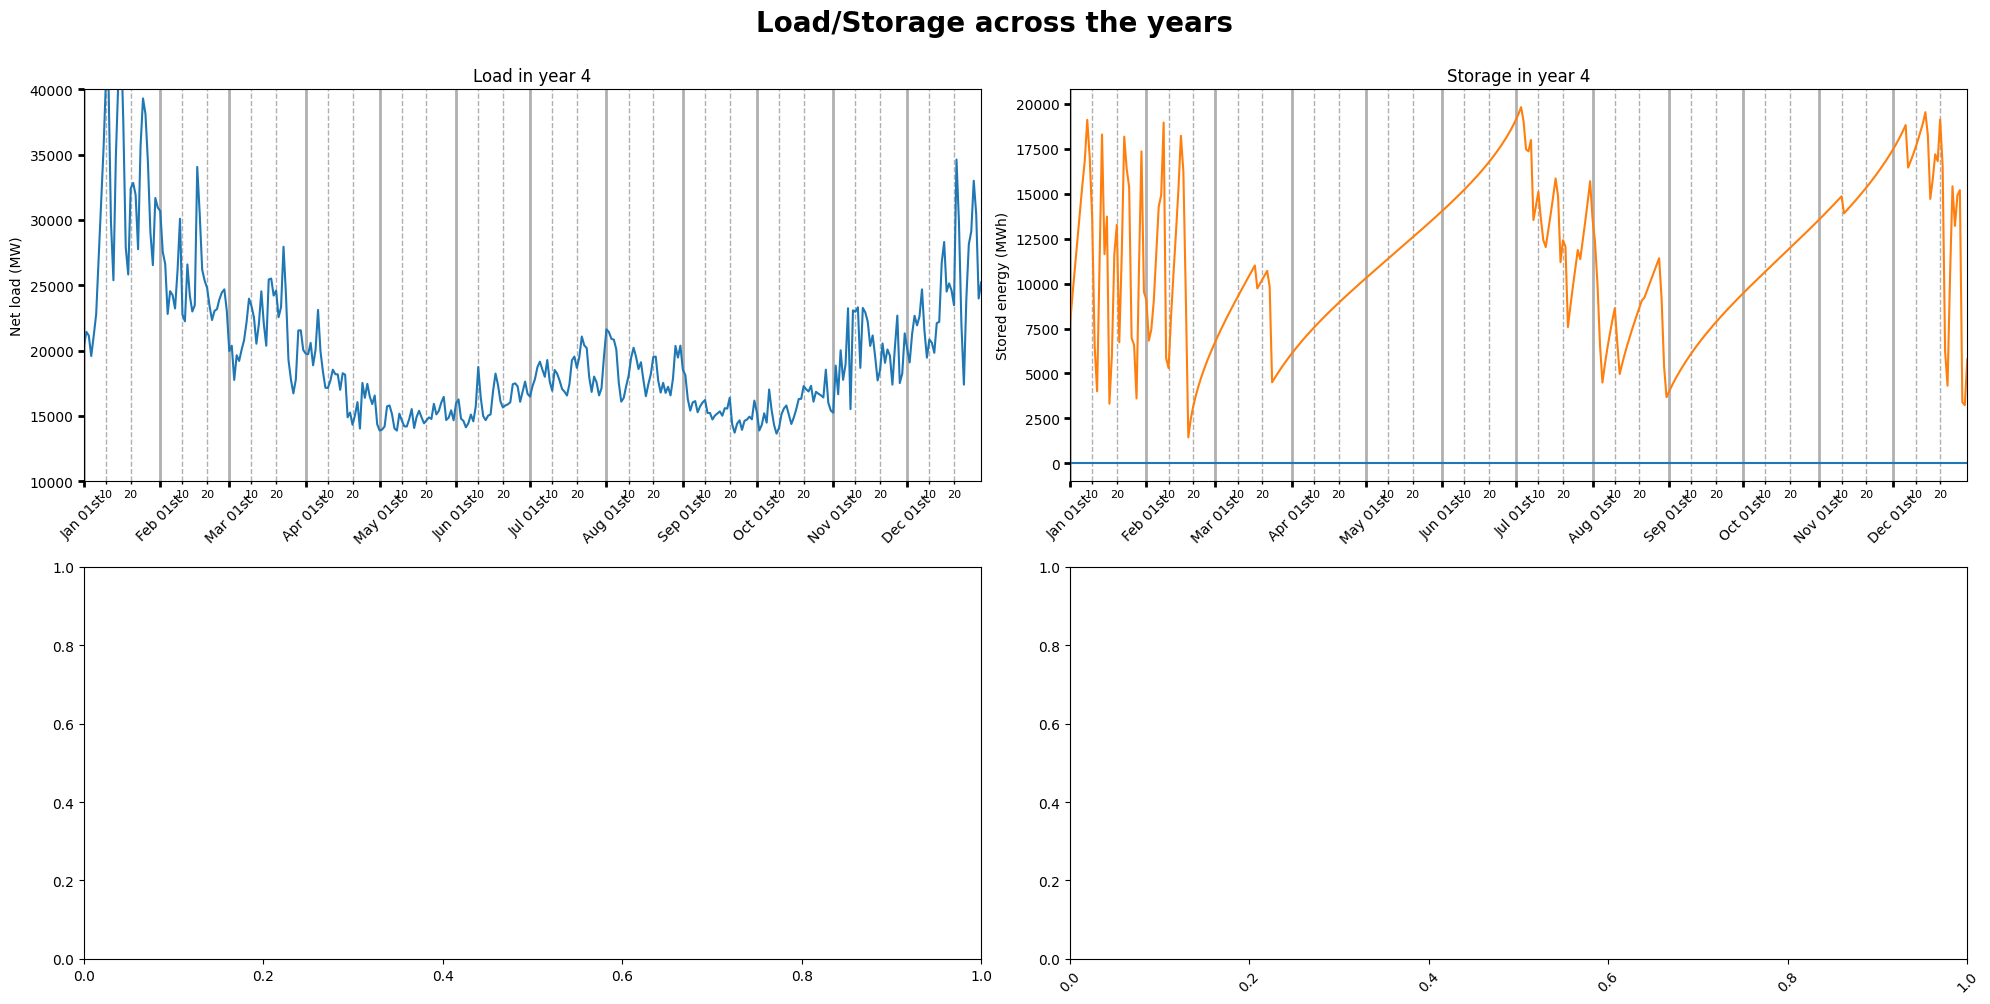

In [17]:
start_tick = 0#480 #31*24
end_tick = 8760#720 #31*24+28*24+1

ref_date = pd.to_datetime('01/01/2050')

start_date = ref_date + pd.DateOffset(hours=start_tick)
end_date = ref_date + pd.DateOffset(hours=end_tick)

x_data = pd.date_range(start=start_date, end=end_date, freq='D', inclusive='left')
x_data_8760 = [(date - ref_date).days*24 for date in x_data]
x_labels = [date.strftime('%b %d') for date in x_data]
x_label_title = [x_data[i].strftime('%B %dth') for i in [0, -1]]

i = 0

if Historical_plot_bool:
    min_row = max(2,nb_years)
    fig,axes = plt.subplots(nrows=min_row, ncols=2, figsize=(20,5*min_row))
    # fig,axes = plt.subplots(nrows=(len(year)//2 + y%2),ncols=2)
    for y in range(1,len(year_list)+1):
        year = year_list[y-1]
        ### For a yearly double-column digest, one with price/load and the second with storage/load.
        # dict_df_years[y]["Load z2"][start_tick:end_tick].plot(figsize=(20,50), ax=axes[y-1][0], title=f"Price/load history in year {y}", xlabel="Time (h)", xlim=(start_tick, end_tick), ylabel="Zonal load (MW)", legend=True)
        # dict_df_years[y]["Price z2"][start_tick:end_tick].plot(figsize=(20,50), ax=axes[y-1][0], secondary_y=True, ylabel="Zonal price ($/MWh_e)", legend=True, xlim=(start_tick, end_tick), ylim=(0,100))

        # dict_df_years[y]["Load z2"][start_tick:end_tick].plot(figsize=(20,50), ax=axes[y-1][1], title=f"Stored energy in year {y}", xlabel="Time (h)",  xlim=(start_tick, end_tick), ylabel="Zonal load (MW)")
        # dict_df_years[y]["Battery z2"][start_tick:end_tick].plot(figsize=(20,50), ax=axes[y-1][1], secondary_y=True, ylabel="Stored energy (MWh)", legend=True)
        # dict_df_years[y]["PHS z2"][start_tick:end_tick].plot(figsize=(20,50), ax=axes[y-1][1], secondary_y=True, legend=True)

        # axes[y-1][0].fill_between(range(8760), 0, 1e5, where=(dict_df_years[y]["Price z2"] > 500), color="r", alpha=0.5)
        # axes[y-1][0].fill_between(range(8760), 0, 1e5, where=(dict_df_years[y]["Price z2"] < 10), color="b", alpha=0.5)

        for j in range(2):
            axes[y-1][j].set_xlim(x_data[0], x_data[-1])

            axes[y-1][j].xaxis.set_major_locator(mdates.MonthLocator())
            axes[y-1][j].xaxis.set_major_formatter(mdates.DateFormatter('%b %dst'))

            axes[y-1][j].tick_params(which='major', width=2)
            axes[y-1][j].tick_params(which='major', length=10)
            axes[y-1][j].tick_params(which='major', axis='x', labelrotation=45)

            axes[y-1][j].xaxis.set_minor_locator(mdates.DayLocator(bymonthday=[10,20]))
            axes[y-1][j].xaxis.set_minor_formatter(mdates.DateFormatter('%d'))
            axes[y-1][j].tick_params(which='minor', width=1)
            axes[y-1][j].tick_params(which='major', length=4)
            axes[y-1][j].tick_params(which='minor', labelsize=8)

            axes[y-1][j].grid(which='major', axis='x', linestyle='-', linewidth=2)
            axes[y-1][j].grid(which='minor', axis='x', linestyle='--', linewidth=1)
        # end for

        axes[y-1][0].plot(x_data, dict_df_years[year]["Load z2"][x_data_8760])
        axes[y-1][0].set_title(f"Load in year {year}")
        axes[y-1][0].set_ylabel("Net load (MW)")
        axes[y-1][0].set_ylim(10e3, 40e3)

        # axes[y-1][0].twinx().plot(x_data, dict_df_years[y]["Price z2"][x_data_8760])
        # axes[y-1][0].twinx().set_ylabel("Price ($/MWh_e)")

        axes[y-1][1].plot(x_data, dict_df_years[year]["Battery z2"][x_data_8760])
        axes[y-1][1].plot(x_data, dict_df_years[year]["PHS z2"][x_data_8760])
        axes[y-1][1].set_title(f"Storage in year {year}")
        axes[y-1][1].set_ylabel("Stored energy (MWh)")

        plt.xticks(rotation=45)



        j = (i + 1)/nb_years
        sys.stdout.write('\r')
        sys.stdout.write(f"[%-20s] %d%%  ---  Plot ready for year {year}!" % ('='*int(20*j), 100*j))
        # sys.stdout.flush()

        ### For a dense digest with all data on yearly subplots

        # dict_df_years[y]["Price z2"][start_tick:end_tick].plot(figsize=(20,50), ax=axes[(y-1)//2][y%2-1], title=f"Price/storage history in year {y}", xlabel="Time (h)", ylabel="Zonal price ($)")

        # dict_df_years[y]["Battery z2"][start_tick:end_tick].plot(figsize=(20,50), ax=axes[(y-1)//2][y%2-1], ylabel="Stored energy (MWh)", secondary_y=True, legend=True)
        # dict_df_years[y]["PHS z2"][start_tick:end_tick].plot(figsize=(20,50), ax=axes[(y-1)//2][y%2-1], secondary_y=True, legend=True)

        # axes[(y-1)//2][y%2-1].legend(loc="upper left")
        # axes[(y-1)//2][y%2-1].right_ax.legend(loc="upper right")
        
        i += 1
    #end for
    plt.suptitle(t='Load/Storage across the years', y=1, fontsize=20, fontweight='bold')
    plt.tight_layout()
else:
    print("Activate the boolean filter to calculate and display the plot")
# end if

### Random time segment plot

In [20]:
start_tick = 197*24 #480 for winter, 100*24 for spring, 197*24 for mid-July, 250*24 for fall
end_tick = start_tick + 12*24

target_y = year_list[0]

Load_z2_plot_bool = True
Solar_z2_plot_bool = True
Wind_z2_plot_bool = False
VRE_z2_plot_bool = False
Storage_z2_plot_bool = False
Firm_z2_plot_bool = True

Production_plot_bool = Solar_z2_plot_bool + Wind_z2_plot_bool + VRE_z2_plot_bool + Storage_z2_plot_bool + Firm_z2_plot_bool

Price_z2_plot_bool = True

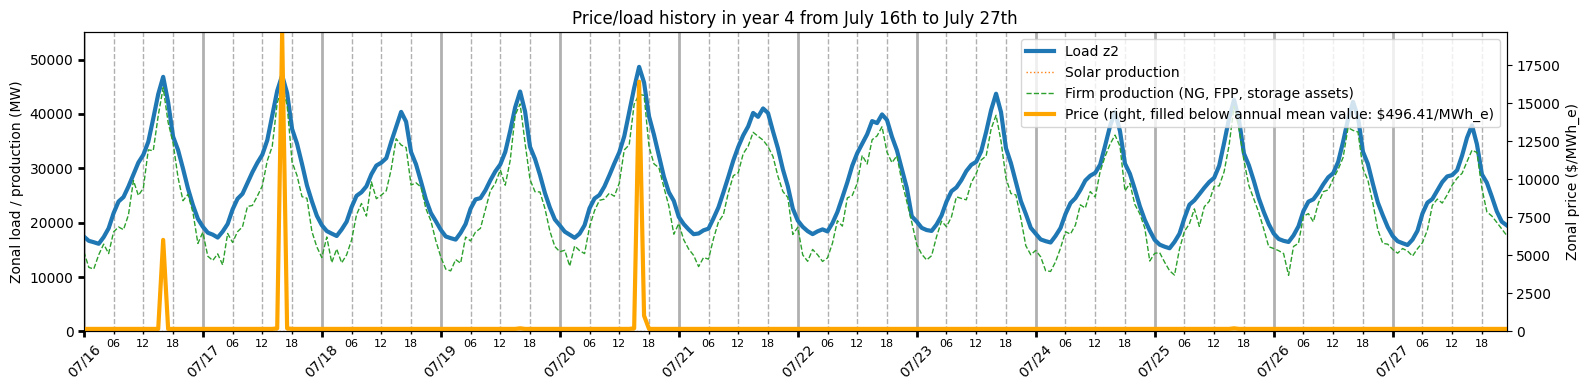

In [22]:
from matplotlib.ticker import (MultipleLocator, AutoMinorLocator)
import matplotlib.dates as mdates

ref_date = pd.to_datetime('01/01/2024')

start_date = ref_date + pd.DateOffset(hours=start_tick)
end_date = ref_date + pd.DateOffset(hours=end_tick)

x_data = pd.date_range(start=start_date, end=end_date, freq='h', inclusive='left')
x_labels = [date.strftime('%m/%d - %H%p') for date in x_data]
x_label_title = [x_data[i].strftime('%B %dth') for i in [0, -1]]

y = target_y

tech_to_plot = {}


if Temporal_segment_bool:
    fig, ax = plt.subplots(nrows=1,ncols=1, figsize =(16,4))
    line_list = []
    line_label_list = []

    if Load_z2_plot_bool:
        load_line, = ax.plot(x_data, dict_df_years[y]["Load z2"][start_tick:end_tick], lw=3)
        line_list.append(load_line)
        line_label_list.append("Load z2")

    solar_production = dict_df_years[y]["Solar PV z2"][start_tick:end_tick] + dict_df_years[y]["Comm solar PV z2"][start_tick:end_tick] + dict_df_years[y]["Res solar PV z2"][start_tick:end_tick]
    
    if Solar_z2_plot_bool:
        solar_line, = ax.plot(x_data, solar_production, ls=":", lw=1)
        line_list.append(solar_line)
        line_label_list.append("Solar production")

    wind_production = dict_df_years[y]["Onshore wind z2"][start_tick:end_tick] + dict_df_years[y]["Fixed offshore wind z2"][start_tick:end_tick] + dict_df_years[y]["Floating offshore wind z2"][start_tick:end_tick]
    if Wind_z2_plot_bool:
        wind_line, = ax.plot(x_data, wind_production)
        line_list.append(wind_line)
        line_label_list.append("Wind production")

    ror_production = dict_df_years[y]["RoR z2"][start_tick:end_tick]

    VRE_production = solar_production + wind_production + ror_production
    if VRE_z2_plot_bool:
        VRE_line, = ax.plot(x_data, VRE_production, ls="--", lw=1)
        line_list.append(VRE_line)
        line_label_list.append("VRE production")

    storage_production = dict_df_years[y]["Battery flow z2"][start_tick:end_tick] + dict_df_years[y]["PHS flow z2"][start_tick:end_tick]
    if Storage_z2_plot_bool:
        storage_line, = ax.plot(x_data, storage_production)
        line_list.append(storage_line)
        line_label_list.append("Storage production")
    
    firm_production = dict_df_years[y]["Hydro z1"][start_tick:end_tick] - dict_df_years[y]["Load z1"][start_tick:end_tick] + dict_df_years[y]["NG z2"][start_tick:end_tick] + dict_df_years[y]["NG-CCS z2"][start_tick:end_tick] + dict_df_years[y]["Battery flow z2"][start_tick:end_tick] + dict_df_years[y]["PHS flow z2"][start_tick:end_tick] + dict_df_years[y]["Fusion z2"][start_tick:end_tick]
    if Firm_z2_plot_bool:
        firm_line, = ax.plot(x_data, firm_production, ls="--", lw=1)
        line_list.append(firm_line)
        line_label_list.append("Firm production (NG, FPP, storage assets)")

    ax.set_title(f"Price/load history in year {y} from {x_label_title[0]} to {x_label_title[-1]}")
    if Production_plot_bool:
        if Load_z2_plot_bool:
            ax.set_ylabel("Zonal load / production (MW)")
        else:
            ax.set_ylabel("Production (MW)")
    elif Load_z2_plot_bool:
        ax.set_ylabel("Zonal load (MW)")
    # end if
    ax.set_xlim(x_data[0], x_data[-1])

    if Storage_z2_plot_bool:
        ax.set_ylim(-5000, 55000)
    else:
        ax.set_ylim(0, 55000)

    if Price_z2_plot_bool:
        sec_ax=ax.twinx()
        price_line, = sec_ax.plot(x_data, dict_df_years[y]["Price z2"][start_tick:end_tick], color='orange', lw=3)

        mean_annual_price = dict_df_years[y]["Price z2"].mean()
        sec_ax.set_ylim(0,dict_df_years[y]["Price z2"][start_tick:end_tick].max())
        sec_ax.set_ylabel("Zonal price ($/MWh_e)")
        line_list.append(price_line)
        line_label_list.append(f"Price (right, filled below annual mean value: ${mean_annual_price:,.2f}/MWh_e)")

    sec_ax.fill_between(x_data, 0, dict_df_years[y]["Price z2"][start_tick:end_tick], where=(dict_df_years[y]["Price z2"][start_tick:end_tick] <= mean_annual_price), color="orange", alpha=0.3)
    
    ax.xaxis.set_major_locator(mdates.DayLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%m/%d'))

    ax.tick_params(which='major', width=2)
    ax.tick_params(which='major', length=10)
    ax.tick_params(which='major', axis='x', labelrotation=45)

    ax.xaxis.set_minor_locator(mdates.HourLocator(byhour=[6,12,18]))
    ax.xaxis.set_minor_formatter(mdates.DateFormatter('%H'))
    ax.tick_params(which='minor', width=1)
    ax.tick_params(which='major', length=4)
    ax.tick_params(which='minor', labelsize=8)

    ax.grid(which='major', axis='x', linestyle='-', linewidth=2)
    ax.grid(which='minor', axis='x', linestyle='--', linewidth=1)

    plt.legend(line_list, line_label_list)

    plt.tight_layout()
    plt.xticks(rotation=45)
else:
    print("Activate the boolean filter to calculate and display the plot")
# end if

### Price distribution

In [23]:
if Price_distribution_bool:
    price_df_y = pd.DataFrame(data=[dict_df_years[y]["Price z2"] for y in year_list], index=[f"Year {y}" for y in year_list]).transpose()
    boxplot_axes = price_df_y.boxplot(figsize=(15,7.5), showfliers=True, return_type="axes")

    plt.title("Price distribution across years")
    plt.ylabel("Zonal price ($/MWh_e)")
    plt.yscale("log")
# end if

### Autocorrelation graph

[========================================] 200%  ---  Plot ready for year 4!

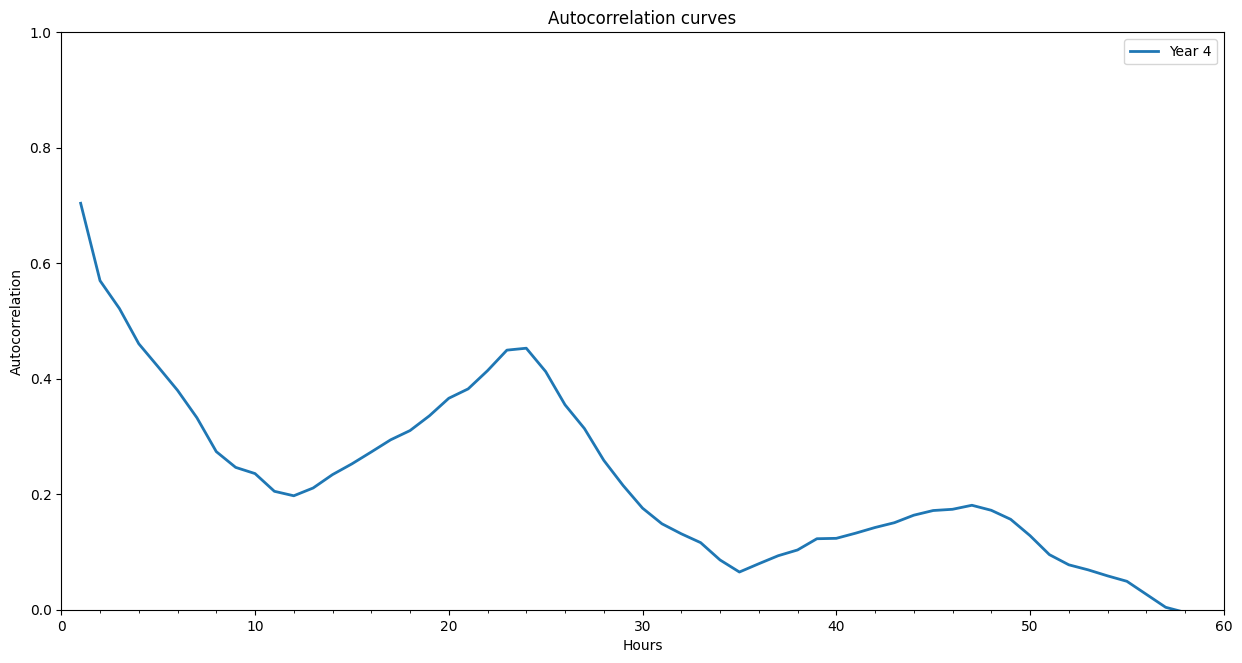

In [24]:
if autocorr_bool:
    hours_autocorr = range(1, 60)

    autocorr_dict = {}
    for y in year_list:
        autocorr_dict_y = {}
        for hour in hours_autocorr:
            autocorr_dict_y.update({hour : dict_df_years[y]["Price z2"].autocorr(hour)})
        autocorr_dict.update({f"Year {y}": autocorr_dict_y})
        # end for
    # end for

    autocorr_df = pd.DataFrame(autocorr_dict)
    # print(autocorr_df)

    fig, axes = plt.subplots(nrows=1,ncols=1, figsize=(15,7.5))
    for y in year_list:
        x_lb = 0
        x_ub = 60

        y_lb = 0
        y_ub = 1
        
        if autocorr_df.loc[1, f"Year {y}"] > 0.6 or autocorr_df.loc[1, f"Year {y}"] < 0.2:
            autocorr_df.loc[:, f"Year {y}"].plot(ax=axes, xlim=(x_lb,x_ub), ylim=(y_lb, y_ub), title=f"Autocorrelation curves", xlabel="Hours", ylabel="Autocorrelation", legend=True, ls="-", lw=2)
        else:
            autocorr_df.loc[:, f"Year {y}"].plot(ax=axes, xlim=(x_lb,x_ub), ylim=(y_lb, y_ub), title=f"Autocorrelation curves", xlabel="Hours", ylabel="Autocorrelation", ls="--", lw=1)

        j = (i + 1)/nb_years
        sys.stdout.write('\r')
        sys.stdout.write(f"[%-20s] %d%%  ---  Plot ready for year {y}!" % ('='*int(20*j), 100*j))
        # sys.stdout.flush()

        i += 1
    # end for

    axes.xaxis.minorticks_on()
# end if

### VRE availability

In [25]:
if Variability_plot_bool:

    start_tick = 0
    end_tick = 8760

    tech_var_dict = {0 : "Solar PV availability", 1 : "Comm Solar PV availability", 2 : "Res Solar PV availability", 3 : "Onshore wind availability", 4 : "Fixed offshore wind availability", 5 : "Float offshore wind availability"}
    tech_var_num_dict = {}

    for y in year_list:
        tech_var_num_y = {}
        for z in range(len(tech_var_dict)):
            tech_var_num_y.update({tech_var_dict[z] : dict_df_years[y][tech_var_dict[z]].sum()/8760})
        #end for
        tech_var_num_dict.update({y : tech_var_num_y})

        j = (i + 1)/nb_years
        sys.stdout.write('\r')
        sys.stdout.write(f"[%-20s] %d%%  ---  VRE availability report ready for year {y}!" % ('='*int(20*j), 100*j))
        # sys.stdout.flush()

        i += 1
    #end for

    price_threshold = 1e4

    high_price_dict = {}

    for y in year_list:
        high_price_df_y = (dict_df_years[y].loc[dict_df_years[y]["Price z2"] >= price_threshold])
        if high_price_df_y.shape[0] > 0:
            print(f"---------------- YEAR {y} : {high_price_df_y.shape[0]} hours above ${price_threshold}/MWh_e ----------------")
            print(high_price_df_y[["Price z2", "Solar PV availability", "Comm Solar PV availability", "Res Solar PV availability", "Onshore wind availability", "Fixed offshore wind availability", "Float offshore wind availability"]].describe())
            high_price_dict.update({y : high_price_df_y})
        else:
            print(f"No prices recorded above ${price_threshold}/MWh_e in year {y}")
    # end for
    
    tech_var_HP_dict = {}

    for y in high_price_dict.keys():
        tech_var_HP_y = {}
        for z in range(len(tech_var_dict)):
            tech_var_HP_y.update({tech_var_dict[z] : high_price_dict[y][tech_var_dict[z]].sum()/len(high_price_dict[y].index)})
        #end for
        tech_var_HP_dict.update({y : tech_var_HP_y})

        j = (i + 1)/nb_years
        sys.stdout.write('\r')
        sys.stdout.write(f"[%-20s] %d%%  ---  VRE availability report ready for year {y}!" % ('='*int(20*j), 100*j))
        # sys.stdout.flush()

        i += 1
    #end for

    HP_df_2 = pd.DataFrame(tech_var_HP_dict).transpose().drop(16)

    total_SE = 0
    for line in HP_df_2.index:
        total_SE += high_price_dict[line].shape[0]
    # end for

    for column in HP_df_2.columns:
        sum = 0
        for line in HP_df_2.index:
            sum += HP_df_2.loc[line, column] * high_price_dict[line].shape[0]
        # end for
        print(f"Average {column} on {total_SE}: {sum/total_SE}")
    # end for

    i = 0

    fig,axes = plt.subplots(nrows=len(tech_var_dict),ncols=1)
    for y in year_list:
        for z in range(len(tech_var_dict)):
            dict_df_years[y][tech_var_dict[z]][start_tick:end_tick].rename(f"Year {y}: {tech_var_num_dict[y][tech_var_dict[z]]:.1%}").plot(figsize=(20,50), ax=axes[z], title=f"{tech_var_dict[z]} across years", xlabel="Time (h)", xlim=(start_tick, end_tick), ylabel="Relative availability", legend=True)

        j = (i + 1)/nb_years
        sys.stdout.write('\r')
        sys.stdout.write(f"[%-20s] %d%%  ---  Plot ready for year {y}!" % ('='*int(20*j), 100*j))
        # sys.stdout.flush()

        i += 1
    #end for
    plt.tight_layout()
else:
    print("Activate the boolean filter to calculate and display the plot")
# end if

Activate the boolean filter to calculate and display the plot


In [26]:
if Variability_plot_bool:
    print(pd.DataFrame(tech_var_num_dict).transpose().describe())

In [27]:
if Variability_plot_bool:
    print(pd.DataFrame(tech_var_HP_dict))

### Load-duration curves

[====================] 100%  ---  Plot ready for year 4!

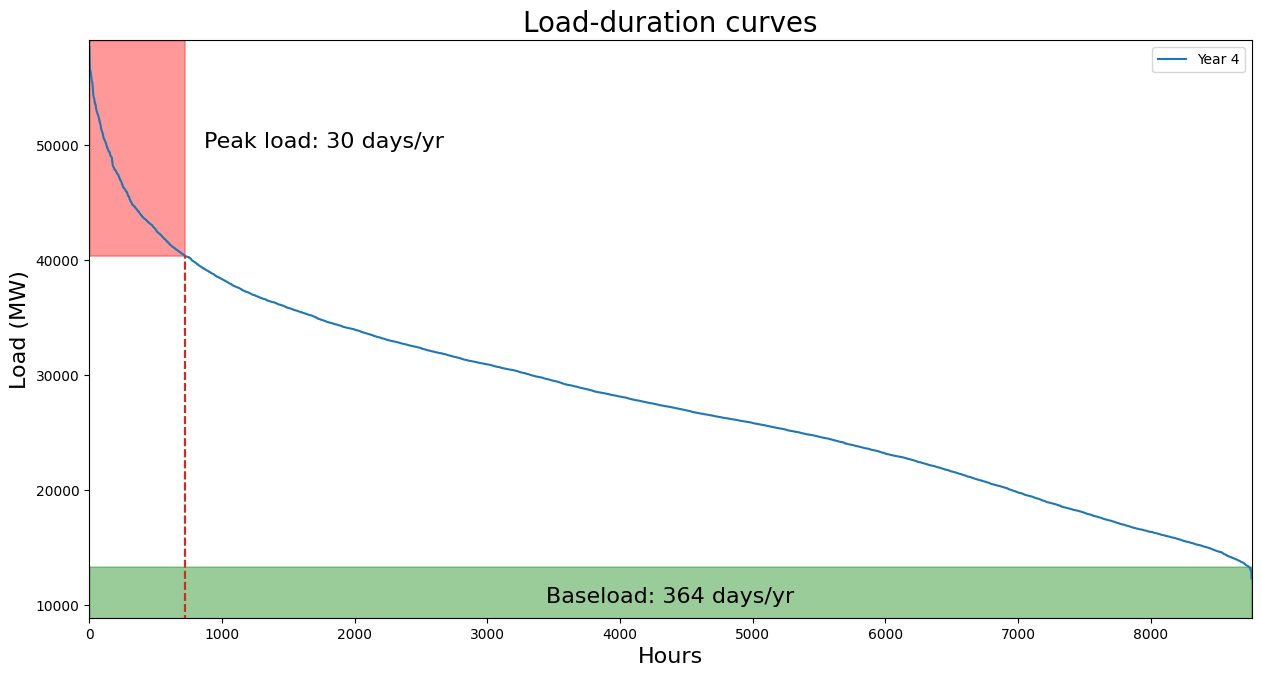

In [28]:
load_duration_dict = {}

i = 0

min_load = 1e5
peak_load = 1e5
max_load = 0

for y in year_list:
    sorted_loads_y = dict_df_years[y]["Load z2"].sort_values(ascending=False, ignore_index=True).rename(f"Year {y}")
    load_duration_dict.update({y : sorted_loads_y})
    min_load_y = sorted_loads_y[364*24]
    peak_load_y = sorted_loads_y[30*24]
    max_load_y = sorted_loads_y[0]
    if min_load_y < min_load:
        min_load = min_load_y
    # end if
    if peak_load_y < peak_load:
        peak_load = peak_load_y
    # end if
    if max_load_y > max_load:
        max_load = max_load_y
    # end if
    
# end for

if Price_duration_curve_bool:
    fig, axes = plt.subplots(nrows=1,ncols=1, figsize=(15,7.5))
    for y in year_list:
        x_lb = 0
        x_ub = 8760

        y_lb = min_load/1.5
        y_ub = max_load
        
        load_duration_dict[y].plot(ax=axes, xlim=(x_lb,x_ub), ylim=(y_lb, y_ub), legend=True, logy=False)

        plt.title(label=f"Load-duration curves", fontsize=20)
        plt.xlabel(xlabel="Hours", fontsize=16)
        plt.ylabel(ylabel="Load (MW)", fontsize=16)

        j = (i + 1)/nb_years
        sys.stdout.write('\r')
        sys.stdout.write(f"[%-20s] %d%%  ---  Plot ready for year {y}!" % ('='*int(20*j), 100*j))
        # sys.stdout.flush()

        i += 1
    # end for

    x_points_peak = [30*24, 30*24]
    y_points_peak = [0, peak_load]

    plt.plot(x_points_peak, y_points_peak, linestyle='dashed')

    x_points_peak = [30*24, 30*24]
    y_points_peak = [0, peak_load]

    plt.plot(x_points_peak, y_points_peak, linestyle='dashed')

    x_points_peak = [30*24, 30*24]
    y_points_peak = [0, peak_load]

    plt.plot(x_points_peak, y_points_peak, linestyle='dashed')

    axes.fill_between(range(x_ub), 0, min_load, where=[True for i in range(x_ub)], color="g", alpha=.4)
    axes.text(1/2 * axes.get_xlim()[-1], min_load/1.25, f"Baseload: 364 days/yr", fontsize=16, horizontalalignment='center', verticalalignment='center',)

    # axes.fill_between(range(x_ub), min_load, peak_load, where=[True for i in range(x_ub)], color="b", alpha=.4)
    # axes.text(1/5 * axes.get_xlim()[-1], (peak_load-min_load)/2 + min_load-9, f"Intermediate", fontsize=16)

    axes.fill_between(range(24*30), peak_load, max_load, where=[True for i in range(24*30)], color="r", alpha=.4)
    axes.text(1.2 * 24*30, (axes.get_ylim()[-1]-peak_load)/2 + peak_load-9, f"Peak load: 30 days/yr", fontsize=16)

else:
    print("Activate the boolean filter to calculate and display the plot")
# end if

### Price duration curves

[====================] 100%  ---  Plot ready for year 4! Scaricity count: 0

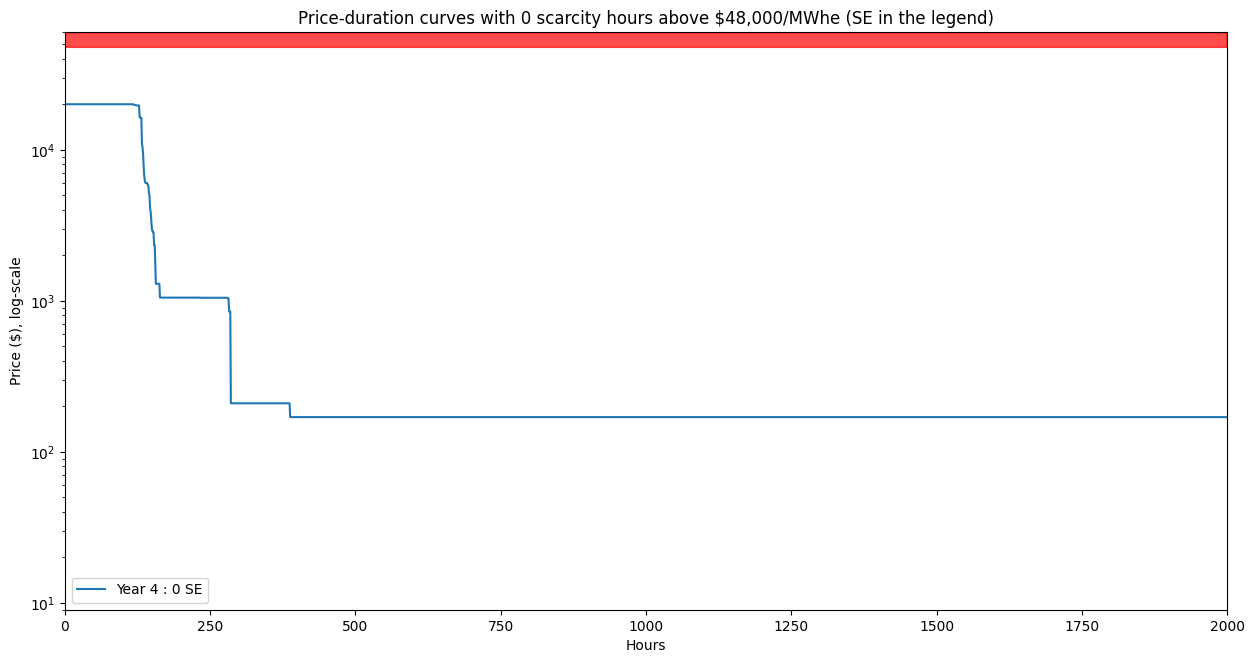

In [29]:
price_duration_dict = {}
scarcity_dict = {}

scarcity_counter = 0
scarcity_price = 48e3

x_lb, x_ub = 0, 2000
y_lb, y_ub = 9, 60e3

i = 0

for y in year_list:
    scarcity_count_y = (dict_df_years[y]["Price z2"] >= scarcity_price).sum()
    scarcity_counter += scarcity_count_y
    sorted_prices_y = dict_df_years[y]["Price z2"].sort_values(ascending=False, ignore_index=True).rename(f"Year {y} : {scarcity_count_y} SE")
    # print(f"Scarcity hours in year {y}: {scarcity_count_y}")
    scarcity_dict.update({y : int(scarcity_count_y)})
    price_duration_dict.update({y : sorted_prices_y})
# end for

if Price_duration_curve_bool:
    fig, axes = plt.subplots(nrows=1,ncols=1, figsize=(15,7.5))
    for y in year_list:
        x_data = range(x_lb, x_ub)
        
        price_duration_dict[y].plot(ax=axes, xlim=(x_lb,x_ub), ylim=(y_lb, y_ub), title=f"Price-duration curves with {scarcity_counter} scarcity hours above ${scarcity_price:,.0f}/MWhe (SE in the legend)", xlabel="Hours", ylabel="Price ($), log-scale", legend=True, logy=True)

        axes.fill_between(x_data, scarcity_price, axes.get_ylim()[-1], where=[True for x in x_data], color="red", alpha=.7)

        # sns.histplot(dict_df_years[y]["Price z2"], kde=False).set_yscale('log')
        # dict_df_years[y]["Price z2"].plot.hist(ax=axes)

        j = (i + 1)/nb_years
        sys.stdout.write('\r')
        sys.stdout.write(f"[%-20s] %d%%  ---  Plot ready for year {y}! Scaricity count: {scarcity_count_y}" % ('='*int(20*j), 100*j))
        # sys.stdout.flush()

        i += 1
    # end for
else:
    print("Activate the boolean filter to calculate and display the plot")
# end if